# WFR-ABF for a dimer in a WCA solvent

Classical dimer-in-solvent example from *Free Energy Computations: A Mathematical Perspective*, Section 5.1.5, Section 1.3.2.4, and Section 2.5.2.3.

## Background

We simulate $N$ particles in a two-dimensional periodic square box. A configuration is

$$
q = (q_1,\ldots,q_N), \qquad q_i \in \mathbb{R}^2.
$$

Particles $q_1$ and $q_2$ are the dimer. Particles $q_3,\ldots,q_N$ are the WCA solvent.

### Potential
The WCA potential is a truncated and shifted Lennard-Jones repulsion:
$$
V_{\rm WCA}(r)=
\begin{cases}
4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12}
-\left(\frac{\sigma}{r}\right)^6\right]+\varepsilon,
& r\le r_0,\\
0,& r>r_0,
\end{cases}
$$
where $r_0 = 2^{1/6}\sigma$.

The interaction between two dimers is the double-well bond potential
$$
V_S(r)=h\left[1-\frac{(r-r_0-w)^2}{w^2}\right]^2,
$$
which has minima at $r=r_0$ and $r=r_0+2w$, corresponding to $z=0$ and $z=1$, and a barrier of height $h$ at $r=r_0+w$, corresponding to $z=1/2$.

The total potential is given by
$$
V(q) = V_S(|q_1 - q_2|) + \sum_{3 \leq i < j \leq N} V_{\rm WCA} (|q_i - q_j|) + \sum_{i = 1, 2} \sum_{3 \leq j \leq N} V_{\rm WCA} (|q_i - q_j|).
$$

### Reaction coordinate
The reaction coordinate is
$$
\xi(q) = \frac{|q_1-q_2|-r_0}{2w}.
$$
With this normalization, $\xi=0$ is the compact well and $\xi=1$ is the stretched well.

### Constrained sampling space
We put the particles in a square box following the setup in the numerical experiments in `WCA_dimer`. The square box has side length $L = n_{\rm dim} a$ where the initial solvent positions lie on an $n_{\rm dim}\times n_{\rm dim}$ lattice with spacing $a$.

Periodic boundary conditions mean that positions are stored modulo $L$. Distances use the **minimum-image convention**: for a displacement $d$, replace it by $d - L\,\mathrm{round}(d/L)$ so each component lies in $[-L/2,L/2]$.

In [1]:
import math
import time
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

EPS = 1e-12


@dataclass(frozen=True)
class DimerWCAParams:
    """Physical and numerical parameters for the dimer-in-WCA-solvent model."""

    n_dim: int = 10
    a: float = 1.5

    # WCA parameters.
    sigma: float = 1.0
    epsilon: float = 1.0

    # Dimer double-well parameters.
    h: float = 2.0
    w: float = 2.0

    beta: float = 1.0

    min_r: float = 0.65
    force_clip: float = 250.0

    @property
    def n_particles(self):
        return self.n_dim * self.n_dim

    @property
    def box_length(self):
        return self.n_dim * self.a

    @property
    def r0(self):
        return 2.0 ** (1.0 / 6.0) * self.sigma

    @property
    def wca_cutoff(self):
        return self.r0


@dataclass(frozen=True)
class SimConfig:

    n_replicas: int = 128
    dt: float = 2.0e-3
    n_steps: int = 100_000
    save_every: int = 1000
    seed: int = 42

    z_min: float = -0.2
    z_max: float = 1.2
    n_grid: int = 120

    abf_bandwidth: float = 0.080
    kde_bandwidth: float = 0.070
    fr_kernel_bandwidth: float = 0.07
    abf_smooth_sigma: float = 1.0

    mean_force_sample_clip: float = 500.0
    abf_force_clip: float = 40.0
    abf_warmup_steps: int = 1_000
    estimator_burn_in_steps: int = 1_000

    # Fisher-Rao selection is delayed so ABF first learns a usable bias,
    # then applied as actual fixed-population birth/death events.
    fr_rate: float = 0.4
    score_clip: float = 3.0
    fr_start_steps: int = 1_000
    fr_every: int = 1
    kernelized_fr_every: int = 5

    n_trace: int = 10

    # Heuristic basin labels used only for coarse diagnostics/plots.
    # The scientifically fixed locations are z=0, z=0.5, and z=1;
    # this half-width is a user-chosen window around the barrier at z=0.5.
    barrier_center: float = 0.5
    transition_half_width: float = 0.15


params = DimerWCAParams(n_dim=8)
sim = SimConfig(
    n_replicas=64,
    n_steps=10_000,
    save_every=200,
    abf_warmup_steps=1_000,
    estimator_burn_in_steps=1_000,
    fr_start_steps=1_000,
    fr_every=1,
    kernelized_fr_every=5,
)
z_grid = np.linspace(sim.z_min, sim.z_max, sim.n_grid)
u_target = np.full_like(z_grid, 1.0 / (sim.z_max - sim.z_min))

print(params)
print(sim)
print(f"N = {params.n_particles}, L = {params.box_length:.3f}, r0 = {params.r0:.3f}")


DimerWCAParams(n_dim=8, a=1.5, sigma=1.0, epsilon=1.0, h=2.0, w=2.0, beta=1.0, min_r=0.65, force_clip=250.0)
SimConfig(n_replicas=64, dt=0.002, n_steps=10000, save_every=200, seed=42, z_min=-0.2, z_max=1.2, n_grid=120, abf_bandwidth=0.08, kde_bandwidth=0.07, fr_kernel_bandwidth=0.07, abf_smooth_sigma=1.0, mean_force_sample_clip=500.0, abf_force_clip=40.0, abf_warmup_steps=1000, estimator_burn_in_steps=1000, fr_rate=0.4, score_clip=3.0, fr_start_steps=1000, fr_every=1, kernelized_fr_every=5, n_trace=10, barrier_center=0.5, transition_half_width=0.15)
N = 64, L = 12.000, r0 = 1.122


In [2]:
def minimum_image(delta, box_length):
    """Apply the minimum-image convention to displacement vectors."""
    return delta - box_length * np.rint(delta / box_length)


def wrap_positions(q, box_length):
    """Wrap positions into the periodic box [0, L)^2."""
    return np.mod(q, box_length)


def wca_potential_and_derivative(r, params):
    """Return WCA potential V(r) and radial derivative dV/dr.

    The derivative is zero beyond the WCA cutoff. The input r may be an array.
    """
    r_safe = np.maximum(r, params.min_r * params.sigma)
    active = r <= params.wca_cutoff

    inv = params.sigma / r_safe
    inv6 = inv**6
    inv12 = inv6**2

    V = 4.0 * params.epsilon * (inv12 - inv6) + params.epsilon
    dVdr = 4.0 * params.epsilon * (-12.0 * inv12 / r_safe + 6.0 * inv6 / r_safe)

    return np.where(active, V, 0.0), np.where(active, dVdr, 0.0)


def dimer_potential_and_derivative(r, params):
    """Return double-well dimer potential V_S(r) and dV_S/dr."""
    r_safe = np.maximum(r, EPS)
    u = (r_safe - params.r0 - params.w) / params.w
    V = params.h * (1.0 - u**2) ** 2
    dVdr = -4.0 * params.h * u * (1.0 - u**2) / params.w
    return V, dVdr


def clip_forces(forces, force_clip):
    """Clip each particle force vector by magnitude, preserving direction."""
    if force_clip is None:
        return forces
    norm = np.linalg.norm(forces, axis=-1, keepdims=True)
    scale = np.minimum(1.0, force_clip / np.maximum(norm, EPS))
    return forces * scale


def total_energy_and_force(q, params, clip=False):
    """Compute total potential energy and physical forces for many replicas.

    Parameters
    ----------
    q : array, shape (R, N, 2)
        Periodic particle positions for R replicas.
    params : DimerWCAParams
        Physical parameters.
    clip : bool
        If True, clip final force magnitudes for explicit time stepping.

    Returns
    -------
    energy : array, shape (R,)
    forces : array, shape (R, N, 2)
        Physical forces, equal to -grad V.
    parts : dict
        Separate WCA and dimer energy contributions.
    """
    q = np.asarray(q, dtype=float)
    R, N, dim = q.shape
    assert dim == 2
    L = params.box_length

    # Pair displacement delta[i,j] = q_i - q_j under the minimum-image rule.
    delta = minimum_image(q[:, :, None, :] - q[:, None, :, :], L)
    r = np.linalg.norm(delta, axis=-1)

    eye = np.eye(N, dtype=bool)[None, :, :]
    dimer_pair = np.zeros((1, N, N), dtype=bool)
    dimer_pair[:, 0, 1] = True
    dimer_pair[:, 1, 0] = True

    # WCA acts on every pair except self pairs and the dimer-dimer pair.
    wca_mask = (~eye) & (~dimer_pair)
    V_wca, dVdr_wca = wca_potential_and_derivative(r, params)
    V_wca = np.where(wca_mask, V_wca, 0.0)
    dVdr_wca = np.where(wca_mask, dVdr_wca, 0.0)

    r_safe = np.maximum(r, params.min_r * params.sigma)
    pair_force = (-dVdr_wca / np.maximum(r_safe, EPS))[..., None] * delta
    forces = np.sum(pair_force, axis=2)
    energy_wca = 0.5 * np.sum(V_wca, axis=(1, 2))

    # Dimer double-well bond between particles 0 and 1.
    d01 = minimum_image(q[:, 0, :] - q[:, 1, :], L)
    r01 = np.linalg.norm(d01, axis=1)
    V_dim, dVdr_dim = dimer_potential_and_derivative(r01, params)
    f01 = (-dVdr_dim / np.maximum(r01, EPS))[:, None] * d01
    forces[:, 0, :] += f01
    forces[:, 1, :] -= f01

    if clip:
        forces = clip_forces(forces, params.force_clip)

    energy = energy_wca + V_dim
    parts = {"wca": energy_wca, "dimer": V_dim}
    return energy, forces, parts


## Mean force

For the dimer reaction coordinate
$$
\xi(q)=\frac{r-r_0}{2w}, \qquad r=|q_1-q_2|,
$$
we have
$$
\nabla_{q_1}\xi = \frac{e}{2w}, \qquad
\nabla_{q_2}\xi = -\frac{e}{2w}, \qquad
|\nabla \xi|^2 = \frac{1}{2w^2},
$$
with $e = \frac{q_1-q_2}{|q_1-q_2|}$.


A standard local mean force identity says that

$$
F'(z) = \mathbb{E}\left[f(q)\mid \xi(q)=z\right],
$$

where
The local mean force reads
$$
\begin{align*}
f(q) &= \frac{\nabla\xi(q)\cdot\nabla V(q)}{|\nabla\xi(q)|^2} -\frac1\beta\,\mathrm{div}\left(\frac{\nabla\xi(q)}{|\nabla\xi(q)|^2}\right)\\
&= \frac{w}{r}(q_1-q_2)\cdot \left(\nabla_{q_1}V(q)-\nabla_{q_2}V(q)\right) - \frac{2w}{\beta r},
\end{align*}
$$
then the mean force is 
$$
F'(z) = \mathbb{E}\left[f(q) \mid \xi(q)=z\right].
$$
We can thus compute the free energy by numerical integration.

In [3]:
def dimer_displacement_and_length(q, params):
    d01 = minimum_image(q[:, 0, :] - q[:, 1, :], params.box_length)
    r01 = np.linalg.norm(d01, axis=1)
    return d01, np.maximum(r01, EPS)


def reaction_coordinate(q, params):
    _, r01 = dimer_displacement_and_length(q, params)
    return (r01 - params.r0) / (2.0 * params.w)


def grad_xi_dimer(q, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad0 = d01 / (2.0 * params.w * r01[:, None])
    grad1 = -grad0
    return grad0, grad1


def local_mean_force(q, physical_forces, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad_difference = physical_forces[:, 1, :] - physical_forces[:, 0, :]
    energetic = (params.w / r01) * np.einsum("ij,ij->i", d01, grad_difference)
    entropic = (2.0 * params.w) / (params.beta * r01)
    return energetic - entropic


def add_abf_force(q, forces, mean_force_at_z, params):
    grad0, grad1 = grad_xi_dimer(q, params)
    forces = forces.copy()
    forces[:, 0, :] += mean_force_at_z[:, None] * grad0
    forces[:, 1, :] += mean_force_at_z[:, None] * grad1
    return forces


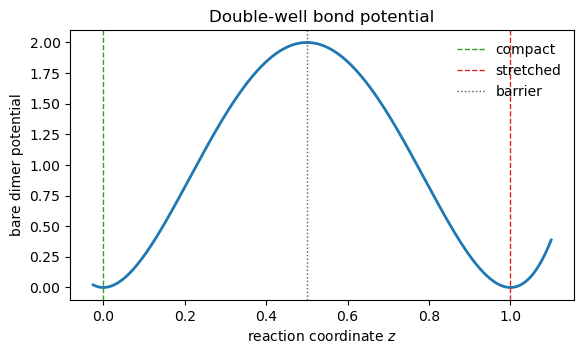

In [4]:
r_values = np.linspace(params.r0 - 0.1, params.r0 + 2.0 * params.w + 0.4, 400)
z_values = (r_values - params.r0) / (2.0 * params.w)
V_dimer, dV_dimer = dimer_potential_and_derivative(r_values, params)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(z_values, V_dimer, color="tab:blue", lw=2)
ax.axvline(0.0, color="tab:green", ls="--", lw=1, label="compact")
ax.axvline(1.0, color="tab:red", ls="--", lw=1, label="stretched")
ax.axvline(0.5, color="0.35", ls=":", lw=1, label="barrier")
ax.set_xlabel(r"reaction coordinate $z$")
ax.set_ylabel("bare dimer potential")
ax.set_title("Double-well bond potential")
ax.legend(frameon=False)
plt.show()


## Methods

### Langevin dynamics

We use overdamped Langevin dynamics

$$
dq_t = -\nabla V(q_t)\,dt + \sqrt{\frac{2}{\beta}}\,dW_t.
$$

Euler-Maruyama gives

$$
q^{n+1} = q^n + F(q^n)\Delta t + \sqrt{\frac{2\Delta t}{\beta}}G^n,
$$

where $F=-\nabla V$ and $G^n$ is a standard Gaussian vector with the same dimension as $q$.

### Adaptive Biasing Force

For ABF we replace $F$ in Langevin dynamics by

$$
F(q) + \widehat F'(\xi(q))\nabla\xi(q).
$$

For WFR-ABF we then apply an additional birth-death step in reaction-coordinate space.


ABF estimates the derivative of the free energy by conditional averaging local mean forces:
$$
F'(z)=\mathbb{E}[f(q)\mid \xi(q)=z].
$$

In simulation we use a Gaussian kernel estimator on a grid:
$$
\widehat F'(z_m) = \frac{\sum_i K_h(z_m-z_i)f(q_i)}{\sum_i K_h(z_m-z_i)}.
$$

In [5]:
def gaussian_kernel(x, bandwidth):
    bw = max(float(bandwidth), EPS)
    return np.exp(-0.5 * (x / bw) ** 2) / (bw * math.sqrt(2.0 * math.pi))


def smooth_profile(y, sigma_grid_points):
    sigma = float(sigma_grid_points)
    if sigma <= 0.0:
        return y.copy()
    radius = max(1, int(math.ceil(4.0 * sigma)))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= np.sum(kernel)
    padded = np.pad(y, (radius, radius), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def cumulative_trapezoid(y, x):
    out = np.zeros_like(y, dtype=float)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out


def normalize_profile_zero_at_midpoint(profile, z_grid, midpoint=0.5):
    idx = int(np.argmin(np.abs(z_grid - midpoint)))
    return profile - profile[idx]


class KernelABFEstimator:

    def __init__(self, z_grid, bandwidth, smooth_sigma=0.0, eps=1e-10):
        self.z_grid = np.asarray(z_grid, dtype=float)
        self.bandwidth = float(bandwidth)
        self.smooth_sigma = float(smooth_sigma)
        self.eps = float(eps)
        self.num = np.zeros_like(self.z_grid)
        self.den = np.zeros_like(self.z_grid)
        self.n_updates = 0

    def update(self, z_samples, force_samples):
        z_samples = np.asarray(z_samples, dtype=float)
        force_samples = np.asarray(force_samples, dtype=float)
        weights = gaussian_kernel(self.z_grid[:, None] - z_samples[None, :], self.bandwidth)
        self.num += np.sum(weights * force_samples[None, :], axis=1)
        self.den += np.sum(weights, axis=1)
        self.n_updates += len(z_samples)

    def mean_force_profile(self):
        raw = np.divide(self.num, np.maximum(self.den, self.eps))
        # Avoid inventing a bias in completely unseen regions.
        raw = np.where(self.den > self.eps, raw, 0.0)
        return smooth_profile(raw, self.smooth_sigma)

    def evaluate(self, z_samples):
        profile = self.mean_force_profile()
        return np.interp(z_samples, self.z_grid, profile, left=0.0, right=0.0)

    def pmf_profile(self):
        """Thermodynamic PMF estimate, obtained as + integral of F'."""
        pmf = cumulative_trapezoid(self.mean_force_profile(), self.z_grid)
        return normalize_profile_zero_at_midpoint(pmf, self.z_grid)

    def bias_potential_profile(self):
        """Bias potential that compensates the PMF, equal to - integral F'."""
        bias = -cumulative_trapezoid(self.mean_force_profile(), self.z_grid)
        return normalize_profile_zero_at_midpoint(bias, self.z_grid)


### ABF with Fisher-Rao
For the Fisher-Rao selection step, we want the reaction-coordinate marginal $p_t(z)$ to approach the flat target
$$u(z)=\frac{1}{z_{\max}-z_{\min}}, \qquad z\in[z_{\min},z_{\max}].$$

A natural objective is the relative entropy
$$
\mathcal{H}(p\mid \nu)=\int p(z)\log\frac{p(z)}{\nu(z)}\,dz.
$$

The simple Fisher-Rao score uses
$$
S(z)=\log\frac{p_t(z)}{u(z)}
-\mathbb{E}_{p_t}\left[\log\frac{p_t}{u}\right].
$$

The kernelized Fisher-Rao score follows the variant used in `WFRABF.ipynb`:
$$
S_\eta(z_i)=\log\frac{\hat p_\eta(z_i)}{u(z_i)}
+\frac1N\sum_j\frac{K_\eta(z_i-z_j)}{\hat p_\eta(z_j)}
-\int \hat p_\eta(z)\log\frac{\hat p_\eta(z)}{u(z)}\,dz - 1.
$$

Both scores are re-centered after clipping so the discrete selection step keeps the mass-conservation property. The particle method uses balanced replacement: overrepresented replicas are selected for removal, and each removed replica is replaced by a clone drawn from underrepresented regions. The kernelized method is exposed as `kwfr_abf` and uses its own bandwidth `fr_kernel_bandwidth` and update interval `kernelized_fr_every`.


In [6]:
def normalize_density_on_grid(p_grid, z_grid):
    mass = np.trapezoid(p_grid, z_grid)
    if mass <= EPS:
        return np.full_like(p_grid, 1.0 / (z_grid[-1] - z_grid[0]))
    return p_grid / mass


def kde_1d(eval_points, samples, bandwidth, z_min, z_max, eps=1e-12):
    """Reflection KDE on a finite interval [z_min, z_max]."""
    eval_points = np.atleast_1d(np.asarray(eval_points, dtype=float))
    samples = np.asarray(samples, dtype=float)
    reflected = np.concatenate([
        samples,
        2.0 * z_min - samples,
        2.0 * z_max - samples,
    ])
    diff = eval_points[:, None] - reflected[None, :]
    p = np.sum(gaussian_kernel(diff, bandwidth), axis=1) / max(len(samples), 1)
    return np.maximum(p, eps)


def uniform_density_at(z, z_min, z_max, eps=1e-12):
    z = np.asarray(z, dtype=float)
    inside = (z >= z_min) & (z <= z_max)
    u = np.full_like(z, eps, dtype=float)
    u[inside] = 1.0 / (z_max - z_min)
    return u


def recentered_clipped_score(raw_score, score_clip):
    """Clip the score without losing the zero-mean mass constraint."""
    score = np.asarray(raw_score, dtype=float) - np.mean(raw_score)
    for _ in range(3):
        score = np.clip(score, -score_clip, score_clip)
        score = score - np.mean(score)
    return np.clip(score, -score_clip, score_clip)


def fisher_rao_score(z_samples, sim):
    """Compute centered Fisher-Rao score at particle locations."""
    p_at_particles = kde_1d(
        z_samples, z_samples, sim.kde_bandwidth, sim.z_min, sim.z_max, eps=EPS
    )
    u_at_particles = uniform_density_at(z_samples, sim.z_min, sim.z_max, eps=EPS)
    log_ratio = np.log(np.maximum(p_at_particles, EPS)) - np.log(np.maximum(u_at_particles, EPS))
    return recentered_clipped_score(log_ratio, sim.score_clip)


def fisher_rao_kernelized_score(z_samples, grid, sim):
    """Kernelized Fisher-Rao score from WFRABF.ipynb, adapted to uniform target u."""
    bandwidth = sim.fr_kernel_bandwidth
    p_at_particles = kde_1d(
        z_samples, z_samples, bandwidth, sim.z_min, sim.z_max, eps=EPS
    )
    p_grid = kde_1d(grid, z_samples, bandwidth, sim.z_min, sim.z_max, eps=EPS)
    p_grid = normalize_density_on_grid(p_grid, grid)

    u_at_particles = uniform_density_at(z_samples, sim.z_min, sim.z_max, eps=EPS)
    u_grid = uniform_density_at(grid, sim.z_min, sim.z_max, eps=EPS)
    log_ratio_at_particles = (
        np.log(np.maximum(p_at_particles, EPS))
        - np.log(np.maximum(u_at_particles, EPS))
    )
    grid_baseline = np.trapezoid(
        p_grid
        * (np.log(np.maximum(p_grid, EPS)) - np.log(np.maximum(u_grid, EPS))),
        grid,
    )

    diff = z_samples[:, None] - z_samples[None, :]
    kernel_matrix = gaussian_kernel(diff, bandwidth)
    kernel_term = np.mean(kernel_matrix / np.maximum(p_at_particles[None, :], EPS), axis=1)
    raw_score = log_ratio_at_particles + kernel_term - grid_baseline - 1.0
    return recentered_clipped_score(raw_score, sim.score_clip)


def fixed_population_birth_death(q, score, sim, rng, fr_interval=None):
    """Replace overrepresented replicas with clones from underrepresented replicas."""
    R = len(q)
    score = recentered_clipped_score(score, sim.score_clip)
    interval = sim.fr_every if fr_interval is None else fr_interval
    dt_eff = sim.dt * max(int(interval), 1)

    death_weights = np.maximum(score, 0.0)
    birth_weights = np.maximum(-score, 0.0)
    death_mass = np.sum(death_weights)
    birth_mass = np.sum(birth_weights)

    if death_mass <= EPS or birth_mass <= EPS:
        stats = {
            "n_replacement_events": 0,
            "mean_abs_score": float(np.mean(np.abs(score))),
            "score_mean": float(np.mean(score)),
        }
        return q.copy(), stats

    death_prob = np.where(
        death_weights > 0.0,
        1.0 - np.exp(-sim.fr_rate * death_weights * dt_eff),
        0.0,
    )
    death_indices = np.where(rng.uniform(size=R) < death_prob)[0]
    n_events = len(death_indices)

    if n_events == 0:
        stats = {
            "n_replacement_events": 0,
            "mean_abs_score": float(np.mean(np.abs(score))),
            "score_mean": float(np.mean(score)),
        }
        return q.copy(), stats

    birth_prob = birth_weights / birth_mass
    clone_sources = rng.choice(R, size=n_events, replace=True, p=birth_prob)

    q_new = q.copy()
    q_new[death_indices] = q[clone_sources]
    stats = {
        "n_replacement_events": int(n_events),
        "mean_abs_score": float(np.mean(np.abs(score))),
        "score_mean": float(np.mean(score)),
    }
    return q_new, stats


For each iteration, we do:
1. Compute $z_i=\xi(q_i)$ and the local mean force $f(q_i)$.
2. Update the ABF bias estimator of $F'(z)$.
3. After `estimator_burn_in_steps`, update a separate production estimator used for the reported mean force and free energy.
4. Move particles by one overdamped Langevin step with the ABF force.
5. After `fr_start_steps`, compute the Fisher-Rao score every `fr_every` steps.
6. Apply a fixed-population birth/death step that clones underrepresented regions and kills overrepresented regions.


In [7]:
def lattice_initial_conditions(params, n_replicas, rng, jitter=0.015):
    """Create periodic lattice initial conditions with compact dimer bond."""
    n = params.n_dim
    a = params.a
    coords = []
    for i in range(n):
        for j in range(n):
            coords.append(((0.5 + i) * a, (0.5 + j) * a))
    base = np.asarray(coords, dtype=float)

    q = np.repeat(base[None, :, :], n_replicas, axis=0)

    shifts = rng.uniform(0.0, params.box_length, size=(n_replicas, 1, 2))
    q = wrap_positions(q + shifts, params.box_length)

    if jitter > 0.0:
        q[:, 2:, :] = wrap_positions(
            q[:, 2:, :] + jitter * rng.standard_normal(size=q[:, 2:, :].shape),
            params.box_length,
        )

    q[:, 1, :] = wrap_positions(q[:, 0, :] + np.array([0.0, params.r0]), params.box_length)
    return q


## Simulations

In [8]:
def l2_error_to_uniform(p_grid, z_grid, z_min, z_max):
    u = np.full_like(z_grid, 1.0 / (z_max - z_min))
    return math.sqrt(np.trapezoid((p_grid - u) ** 2, z_grid))


def free_energy_from_density(p_grid, grid, beta):
    """Estimate F(z) = - beta^{-1} log p(z), shifted at z=0.5.

    This is meaningful for unbiased equilibrium sampling. It is not the correct
    free energy for biased ABF samples unless reweighting is performed.
    """
    F = -(1.0 / beta) * np.log(np.maximum(p_grid, EPS))
    return normalize_profile_zero_at_midpoint(F, grid)


def mean_force_from_free_energy(free_energy, grid):
    """Differentiate a free-energy profile on the grid."""
    return np.gradient(free_energy, grid, edge_order=2)


def transition_thresholds(sim):
    """Heuristic plotting thresholds around the barrier at z=0.5."""
    low = sim.barrier_center - sim.transition_half_width
    high = sim.barrier_center + sim.transition_half_width
    return low, high


def classify_states(z, sim):
    """Return coarse compact/transition/stretched fractions.

    The thresholds are heuristic diagnostics, not physical constants.
    """
    z = np.asarray(z)
    low, high = transition_thresholds(sim)
    compact = np.mean(z < low)
    stretched = np.mean(z > high)
    transition = 1.0 - compact - stretched
    return compact, transition, stretched


def count_switches(trace, sim):
    """Count compact-stretched switches in one z trajectory with hysteresis."""
    low, high = transition_thresholds(sim)
    state = None
    switches = 0
    for z in trace:
        new_state = state
        if z < low:
            new_state = 0
        elif z > high:
            new_state = 1
        if state is not None and new_state is not None and new_state != state:
            switches += 1
        state = new_state
    return switches


def run_sampler(method, params, sim, initial_q=None, verbose=True):
    """Run unbiased, ABF, WFR-ABF, or kernelized WFR-ABF dynamics."""
    if method not in {"unbiased", "abf", "wfr_abf", "kwfr_abf"}:
        raise ValueError("method must be 'unbiased', 'abf', 'wfr_abf', or 'kwfr_abf'")

    rng = np.random.default_rng(sim.seed)
    if initial_q is None:
        q = lattice_initial_conditions(params, sim.n_replicas, rng)
    else:
        q = np.array(initial_q, dtype=float, copy=True)

    grid = np.linspace(sim.z_min, sim.z_max, sim.n_grid)
    bias_estimator = KernelABFEstimator(
        z_grid=grid,
        bandwidth=sim.abf_bandwidth,
        smooth_sigma=sim.abf_smooth_sigma,
    )
    production_estimator = KernelABFEstimator(
        z_grid=grid,
        bandwidth=sim.abf_bandwidth,
        smooth_sigma=sim.abf_smooth_sigma,
    )
    noise_scale = math.sqrt(2.0 * sim.dt / params.beta)
    total_replacement_events = 0

    diagnostics = {
        "method": method,
        "steps": [],
        "times": [],
        "z_snapshots": [],
        "p_grid": [],
        "l2_marginal": [],
        "mean_force": [],
        "pmf": [],
        "bias_potential": [],
        "hist_free_energy": [],
        "hist_mean_force": [],
        "energy_mean": [],
        "state_fractions": [],
        "trace_z": [],
        "replacement_events": [],
        "mean_abs_score": [],
        "score_mean": [],
    }

    t0 = time.perf_counter()
    for step in range(sim.n_steps + 1):
        energy, physical_forces_raw, _ = total_energy_and_force(q, params, clip=False)
        z = reaction_coordinate(q, params)

        if method in {"abf", "wfr_abf", "kwfr_abf"}:
            f_local = local_mean_force(q, physical_forces_raw, params)
            f_local = np.clip(
                f_local,
                -sim.mean_force_sample_clip,
                sim.mean_force_sample_clip,
            )
            bias_estimator.update(z, f_local)
            if step >= sim.estimator_burn_in_steps:
                production_estimator.update(z, f_local)

            ramp = min(1.0, step / max(sim.abf_warmup_steps, 1))
            abf_at_z = ramp * np.clip(
                bias_estimator.evaluate(z),
                -sim.abf_force_clip,
                sim.abf_force_clip,
            )
        else:
            abf_at_z = np.zeros_like(z)

        transport_forces = clip_forces(physical_forces_raw, params.force_clip)
        if method in {"abf", "wfr_abf", "kwfr_abf"}:
            transport_forces = add_abf_force(q, transport_forces, abf_at_z, params)
            transport_forces = clip_forces(transport_forces, params.force_clip)

        if step % sim.save_every == 0 or step == sim.n_steps:
            report_estimator = production_estimator if production_estimator.n_updates > 0 else bias_estimator
            p_grid = kde_1d(grid, z, sim.kde_bandwidth, sim.z_min, sim.z_max, eps=EPS)
            p_grid = normalize_density_on_grid(p_grid, grid)
            hist_free_energy = free_energy_from_density(p_grid, grid, params.beta)
            hist_mean_force = mean_force_from_free_energy(hist_free_energy, grid)
            compact, transition, stretched = classify_states(z, sim)
            diagnostics["steps"].append(step)
            diagnostics["times"].append(step * sim.dt)
            diagnostics["z_snapshots"].append(z.copy())
            diagnostics["p_grid"].append(p_grid.copy())
            diagnostics["l2_marginal"].append(l2_error_to_uniform(p_grid, grid, sim.z_min, sim.z_max))
            diagnostics["mean_force"].append(report_estimator.mean_force_profile().copy())
            diagnostics["pmf"].append(report_estimator.pmf_profile().copy())
            diagnostics["bias_potential"].append(bias_estimator.bias_potential_profile().copy())
            diagnostics["hist_free_energy"].append(hist_free_energy.copy())
            diagnostics["hist_mean_force"].append(hist_mean_force.copy())
            diagnostics["energy_mean"].append(float(np.mean(energy)))
            diagnostics["state_fractions"].append((compact, transition, stretched))
            diagnostics["trace_z"].append(z[: sim.n_trace].copy())

        if step == sim.n_steps:
            break

        q = q + sim.dt * transport_forces + noise_scale * rng.standard_normal(size=q.shape)
        q = wrap_positions(q, params.box_length)

        if method in {"wfr_abf", "kwfr_abf"}:
            next_step = step + 1
            fr_interval = sim.kernelized_fr_every if method == "kwfr_abf" else sim.fr_every
            do_fr = (
                next_step >= sim.fr_start_steps
                and (next_step - sim.fr_start_steps) % max(int(fr_interval), 1) == 0
            )
            if do_fr:
                z_tilde = reaction_coordinate(q, params)
                if method == "kwfr_abf":
                    score = fisher_rao_kernelized_score(z_tilde, grid, sim)
                else:
                    score = fisher_rao_score(z_tilde, sim)
                q, stats = fixed_population_birth_death(q, score, sim, rng, fr_interval=fr_interval)
                total_replacement_events += stats["n_replacement_events"]
                diagnostics["replacement_events"].append(stats["n_replacement_events"])
                diagnostics["mean_abs_score"].append(stats["mean_abs_score"])
                diagnostics["score_mean"].append(stats["score_mean"])
            else:
                diagnostics["replacement_events"].append(0)
                diagnostics["mean_abs_score"].append(0.0)
                diagnostics["score_mean"].append(0.0)
        else:
            diagnostics["replacement_events"].append(0)
            diagnostics["mean_abs_score"].append(0.0)
            diagnostics["score_mean"].append(0.0)

    diagnostics["q_final"] = q.copy()
    diagnostics["z_final"] = reaction_coordinate(q, params)
    diagnostics["grid"] = grid.copy()
    diagnostics["runtime_seconds"] = time.perf_counter() - t0
    diagnostics["total_replacement_events"] = total_replacement_events

    for key in [
        "steps", "times", "p_grid", "l2_marginal", "mean_force", "pmf",
        "bias_potential", "hist_free_energy", "hist_mean_force",
        "energy_mean", "state_fractions", "trace_z",
    ]:
        diagnostics[key] = np.asarray(diagnostics[key])

    if verbose:
        final_l2 = diagnostics["l2_marginal"][-1]
        compact, transition, stretched = diagnostics["state_fractions"][-1]
        extra = ""
        if method in {"wfr_abf", "kwfr_abf"}:
            extra = f", replacements {total_replacement_events}"
        print(
            f"{method:9s}: runtime {diagnostics['runtime_seconds']:.2f}s, "
            f"Final L2 of marginal distribution {final_l2:.4f}, "
            f"C/T/S {compact:.2f}/{transition:.2f}/{stretched:.2f}{extra}"
        )

    return diagnostics


init_rng = np.random.default_rng(sim.seed)
initial_q = lattice_initial_conditions(params, sim.n_replicas, init_rng)

results = {}
for method in ["unbiased", "abf", "wfr_abf", "kwfr_abf"]:
    results[method] = run_sampler(method, params, sim, initial_q=initial_q, verbose=True)


unbiased : runtime 288.87s, Final L2 of marginal distribution 0.5601, C/T/S 0.39/0.03/0.58
abf      : runtime 272.20s, Final L2 of marginal distribution 0.5837, C/T/S 0.23/0.11/0.66
wfr_abf  : runtime 209.74s, Final L2 of marginal distribution 0.2461, C/T/S 0.28/0.19/0.53, replacements 105
kwfr_abf : runtime 181.96s, Final L2 of marginal distribution 0.2108, C/T/S 0.31/0.19/0.50, replacements 106



## Thermodynamic integration reference

For this WCA dimer system, the reference mean force and free energy are not analytic. The standard numerical route, also used in the book's WCA-dimer material, is thermodynamic integration (TI):

1. choose a grid of reaction-coordinate values $z_k$;
2. for each $z_k$, run constrained dynamics with $\xi(q)=z_k$;
3. estimate

$$
F'(z_k) = \mathbb E[f(q)\mid \xi(q)=z_k]
$$

by averaging the local mean force along the constrained trajectory;
4. integrate the resulting mean-force profile to obtain

$$
F(z) = F(z_0) + \int_{z_0}^z F'(s)\,ds.
$$

This is the notebook's numerical "real" reference. It is still approximate, because it depends on constrained sampling length, number of replicas, and the $z$ grid. Increase `TIConfig` for a stronger reference.


In [9]:

@dataclass(frozen=True)
class TIConfig:
    z_min: float = -0.2
    z_max: float = 1.2
    n_z: int = 31
    n_replicas: int = 32
    dt: float = 2.0e-3
    n_thermalization: int = 2_000
    n_steps: int = 8_000
    sample_every: int = 10
    seed: int = 314159
    smooth_sigma: float = 1.0


def project_dimer_to_z(q, z, params, rng=None):
    """Project the dimer bond to xi(q)=z while preserving its midpoint.

    This is a simple position projection suitable for a pedagogical overdamped
    constrained sampler. It follows the same geometric constraint used in the
    book's thermodynamic-integration discussion: r = r0 + 2 w z.
    """
    target_r = params.r0 + 2.0 * params.w * z
    if target_r <= 0.0:
        raise ValueError(f"Target dimer length must be positive, got {target_r}")

    q_new = np.array(q, copy=True)
    d01, r01 = dimer_displacement_and_length(q_new, params)
    direction = d01 / np.maximum(r01[:, None], EPS)

    bad = r01 < 1.0e-10
    if np.any(bad):
        if rng is None:
            rng = np.random.default_rng()
        theta = rng.uniform(0.0, 2.0 * np.pi, size=np.sum(bad))
        direction[bad, 0] = np.cos(theta)
        direction[bad, 1] = np.sin(theta)

    # The midpoint must be computed using the minimum-image representative of q0-q1.
    midpoint = q_new[:, 1, :] + 0.5 * d01
    target_d = target_r * direction
    q_new[:, 0, :] = midpoint + 0.5 * target_d
    q_new[:, 1, :] = midpoint - 0.5 * target_d
    return wrap_positions(q_new, params.box_length)


def constrained_ti_reference(params, sim, ti, eval_grid=None, verbose=True):
    """Compute a TI reference by constrained overdamped sampling.

    The returned profile is interpolated onto eval_grid, usually the same grid
    used by ABF/WFR-ABF diagnostics.
    """
    rng = np.random.default_rng(ti.seed)
    z_ti = np.linspace(ti.z_min, ti.z_max, ti.n_z)
    mean_force = np.zeros_like(z_ti)
    stderr = np.zeros_like(z_ti)
    noise_scale = math.sqrt(2.0 * ti.dt / params.beta)

    for k, z in enumerate(z_ti):
        q = lattice_initial_conditions(params, ti.n_replicas, rng)
        q = project_dimer_to_z(q, z, params, rng)
        collected = []

        total_steps = ti.n_thermalization + ti.n_steps
        for step in range(total_steps):
            _, physical_forces_raw, _ = total_energy_and_force(q, params, clip=False)
            transport_forces = clip_forces(physical_forces_raw, params.force_clip)
            q = q + ti.dt * transport_forces + noise_scale * rng.standard_normal(size=q.shape)
            q = project_dimer_to_z(wrap_positions(q, params.box_length), z, params, rng)

            if step >= ti.n_thermalization and (step - ti.n_thermalization) % ti.sample_every == 0:
                _, sample_forces, _ = total_energy_and_force(q, params, clip=False)
                collected.append(local_mean_force(q, sample_forces, params))

        samples = np.concatenate(collected)
        mean_force[k] = np.mean(samples)
        stderr[k] = np.std(samples, ddof=1) / math.sqrt(len(samples))

        if verbose:
            print(
                f"TI {k+1:02d}/{ti.n_z}: z={z: .3f}, "
                f"F'={mean_force[k]: .4f} +/- {stderr[k]:.4f}, "
                f"samples={len(samples)}"
            )

    mean_force_smooth = smooth_profile(mean_force, ti.smooth_sigma)
    free_energy_ti = cumulative_trapezoid(mean_force_smooth, z_ti)
    free_energy_ti = normalize_profile_zero_at_midpoint(free_energy_ti, z_ti)

    if eval_grid is None:
        eval_grid = np.linspace(sim.z_min, sim.z_max, sim.n_grid)
    mean_force_eval = np.interp(eval_grid, z_ti, mean_force_smooth)
    free_energy_eval = np.interp(eval_grid, z_ti, free_energy_ti)
    free_energy_eval = normalize_profile_zero_at_midpoint(free_energy_eval, eval_grid)

    return {
        "source": "thermodynamic_integration",
        "label": "thermodynamic integration reference",
        "grid": np.asarray(eval_grid),
        "mean_force": mean_force_eval,
        "free_energy": free_energy_eval,
        "z_ti": z_ti,
        "mean_force_ti_raw": mean_force,
        "mean_force_ti_smooth": mean_force_smooth,
        "free_energy_ti": free_energy_ti,
        "stderr": stderr,
        "config": ti,
    }


ti = TIConfig(
    z_min=sim.z_min,
    z_max=sim.z_max,
    n_z=31,
    n_replicas=32,
    dt=sim.dt,
    n_thermalization=2000,
    n_steps=20_000,
    sample_every=20,
)

ti_reference = constrained_ti_reference(
    params,
    sim,
    ti,
    eval_grid=results["abf"]["grid"],
    verbose=True,
)

TI 01/31: z=-0.200, F'=-14.1547 +/- 2.0153, samples=32000
TI 02/31: z=-0.153, F'=-3.3841 +/- 1.6745, samples=32000
TI 03/31: z=-0.107, F'= 5.7272 +/- 1.9680, samples=32000
TI 04/31: z=-0.060, F'= 8.7166 +/- 1.8154, samples=32000
TI 05/31: z=-0.013, F'= 19.1101 +/- 2.5537, samples=32000
TI 06/31: z= 0.033, F'= 17.5532 +/- 2.6022, samples=32000
TI 07/31: z= 0.080, F'= 14.7783 +/- 2.4341, samples=32000
TI 08/31: z= 0.127, F'= 11.3205 +/- 2.0006, samples=32000
TI 09/31: z= 0.173, F'= 9.8285 +/- 2.7773, samples=32000
TI 10/31: z= 0.220, F'=-9.5422 +/- 3.8386, samples=32000
TI 11/31: z= 0.267, F'=-29.7202 +/- 5.0987, samples=32000
TI 12/31: z= 0.313, F'= 3.0537 +/- 3.1304, samples=32000
TI 13/31: z= 0.360, F'= 2.3069 +/- 2.6405, samples=32000
TI 14/31: z= 0.407, F'= 8.5539 +/- 2.9001, samples=32000
TI 15/31: z= 0.453, F'= 4.5408 +/- 3.0076, samples=32000
TI 16/31: z= 0.500, F'=-0.5385 +/- 3.1249, samples=32000
TI 17/31: z= 0.547, F'=-0.5881 +/- 3.3574, samples=32000
TI 18/31: z= 0.593, F'=-0


## Diagnostics and visualizations


method      marginal L2   compact  transition  stretched   L2 F'   L2 F
unbiased        0.5601     0.39        0.03       0.58   8.874  1.058
abf             0.5837     0.23        0.11       0.66   6.020  0.808
wfr_abf         0.2461     0.28        0.19       0.53   5.805  0.618   replacements=105
kwfr_abf        0.2108     0.31        0.19       0.50   5.889  0.671   replacements=106
heuristic thresholds: compact z<0.35, transition 0.35<=z<=0.65, stretched z>0.65
uniform target fractions: compact/transition/stretched = 0.39/0.21/0.39
reference: thermodynamic integration reference


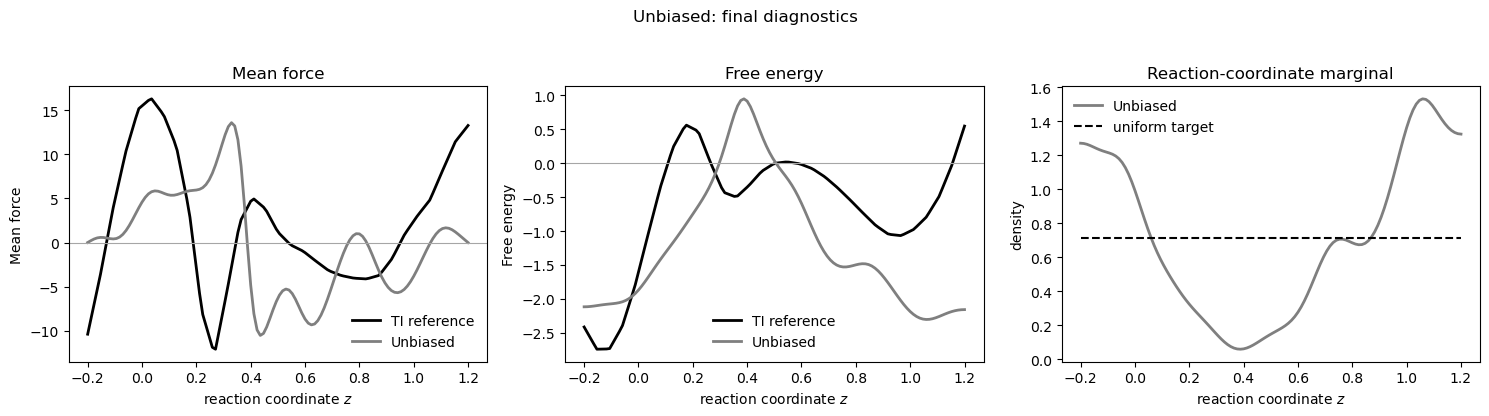

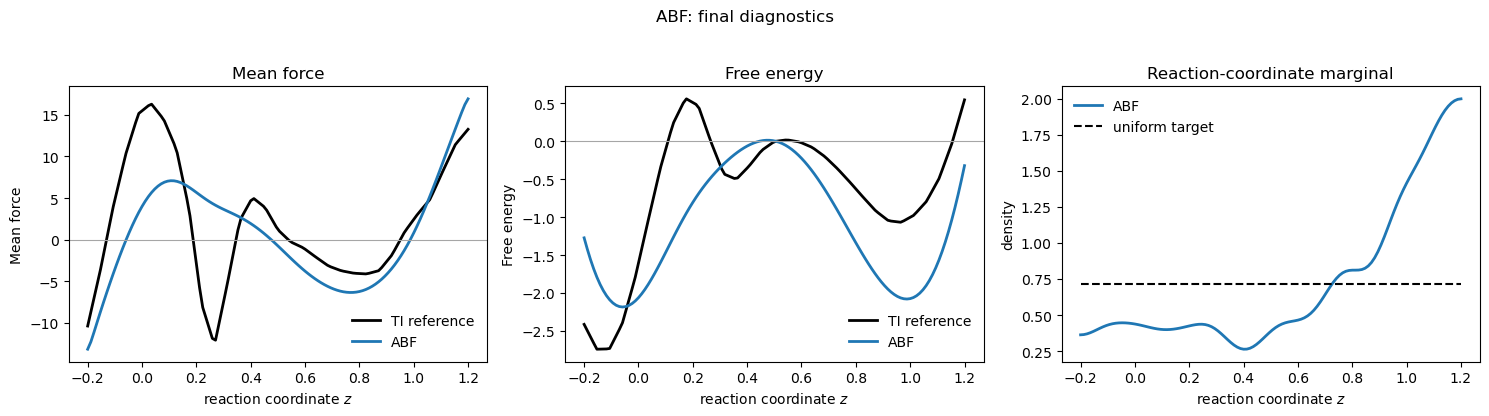

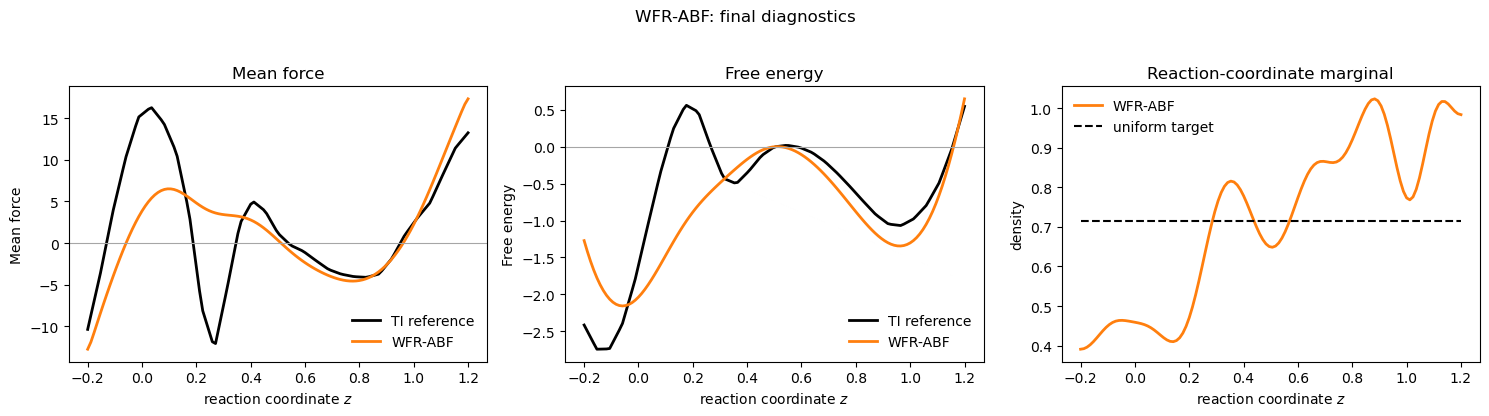

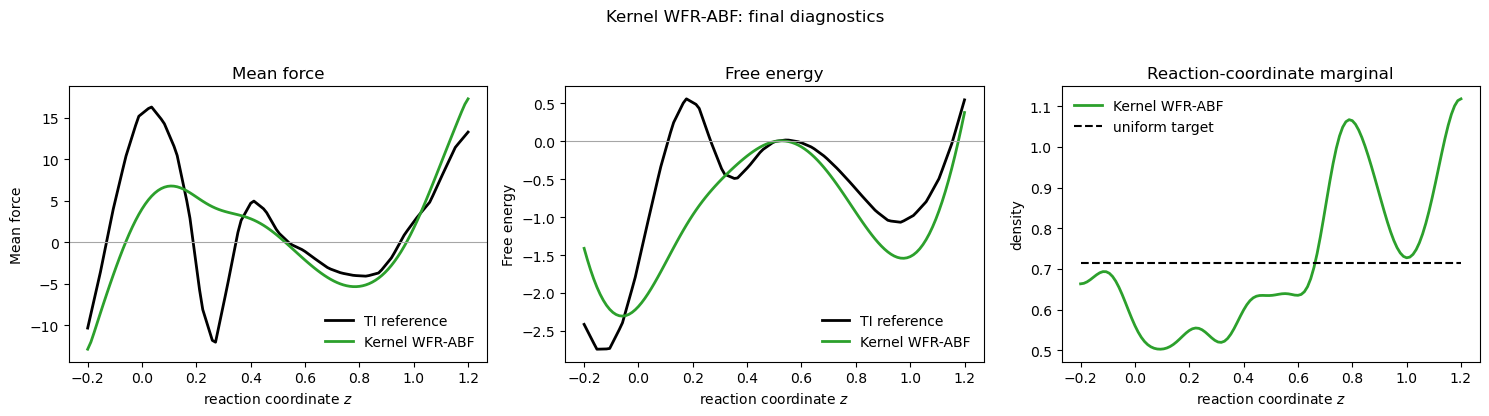

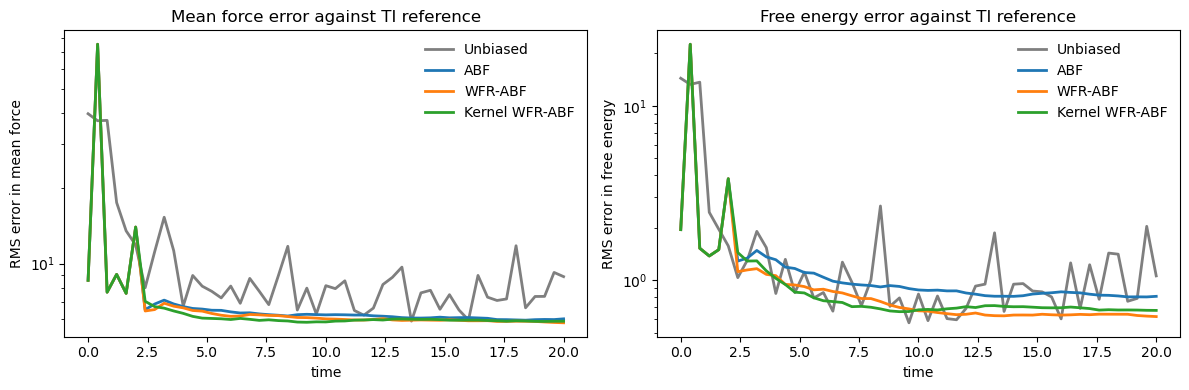

In [10]:

def require_results(results):
    if not results:
        raise RuntimeError("Run the experiment cell first.")


METHOD_ORDER = ["unbiased", "abf", "wfr_abf", "kwfr_abf"]
METHOD_LABELS = {"unbiased": "Unbiased", "abf": "ABF", "wfr_abf": "WFR-ABF", "kwfr_abf": "Kernel WFR-ABF"}
METHOD_COLORS = {"unbiased": "tab:gray", "abf": "tab:blue", "wfr_abf": "tab:orange", "kwfr_abf": "tab:green"}


def profile_l2_error(profile, reference, grid):
    """Grid-normalized L2 error for one scalar profile."""
    return math.sqrt(
        np.trapezoid((np.asarray(profile) - np.asarray(reference)) ** 2, grid)
        / (grid[-1] - grid[0])
    )

def estimated_profile_series(res):
    """Return the method's mean-force and free-energy estimates over time.

    Unbiased Langevin has no ABF estimator, so we use the equilibrium histogram
    estimate F(z)=-beta^{-1}log p(z) and its derivative. ABF and WFR-ABF use
    their adaptive mean-force estimator and its integral.
    """
    if res["method"] == "unbiased":
        return res["hist_mean_force"], res["hist_free_energy"]
    return res["mean_force"], res["pmf"]


def final_estimated_profiles(res):
    mf_series, fe_series = estimated_profile_series(res)
    return mf_series[-1], fe_series[-1]


def attach_reference_errors(results, reference):
    """Attach time-dependent L2 errors against the TI reference."""
    ref_grid = reference["grid"]
    ref_mf = reference["mean_force"]
    ref_fe = reference["free_energy"]

    for key, res in results.items():
        if not np.allclose(res["grid"], ref_grid):
            raise ValueError("All methods must use the same z-grid for this diagnostic.")
        mf_series, fe_series = estimated_profile_series(res)
        res["l2_mean_force_ref"] = np.array([
            profile_l2_error(profile, ref_mf, ref_grid)
            for profile in mf_series
        ])
        res["l2_free_energy_ref"] = np.array([
            profile_l2_error(profile, ref_fe, ref_grid)
            for profile in fe_series
        ])


def uniform_state_fractions(sim):
    low, high = transition_thresholds(sim)
    total = sim.z_max - sim.z_min
    compact = max(0.0, min(low, sim.z_max) - sim.z_min) / total
    transition = max(0.0, min(high, sim.z_max) - max(low, sim.z_min)) / total
    stretched = max(0.0, sim.z_max - max(high, sim.z_min)) / total
    return compact, transition, stretched


def summarize_results(results, reference=None, sim=None):
    require_results(results)
    header = "method      marginal L2   compact  transition  stretched"
    if reference is not None:
        header += "   L2 F'   L2 F"
    print(header)
    for key in METHOD_ORDER:
        res = results[key]
        compact, transition, stretched = res["state_fractions"][-1]
        line = (
            f"{key:9s}  {res['l2_marginal'][-1]:11.4f} "
            f"{compact:8.2f} {transition:11.2f} {stretched:10.2f}"
        )
        if reference is not None:
            line += f" {res['l2_mean_force_ref'][-1]:7.3f} {res['l2_free_energy_ref'][-1]:6.3f}"
        if key in {"wfr_abf", "kwfr_abf"} and "total_replacement_events" in res:
            line += f"   replacements={res['total_replacement_events']}"
        print(line)

    if sim is not None:
        c, t, s = uniform_state_fractions(sim)
        low, high = transition_thresholds(sim)
        print(f"heuristic thresholds: compact z<{low:.2f}, transition {low:.2f}<=z<={high:.2f}, stretched z>{high:.2f}")
        print(f"uniform target fractions: compact/transition/stretched = {c:.2f}/{t:.2f}/{s:.2f}")


def plot_method_diagnostics(results, method, reference, sim):

    res = results[method]
    grid = res["grid"]
    color = METHOD_COLORS[method]
    label = METHOD_LABELS[method]

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.0))

    mean_force_est, free_energy_est = final_estimated_profiles(res)

    axes[0].plot(reference["grid"], reference["mean_force"], color="black", lw=2.0,
                 label="TI reference")
    axes[0].plot(grid, mean_force_est, color=color, lw=2.0, label=label)
    axes[0].axhline(0.0, color="0.65", lw=0.8)
    axes[0].set_xlabel(r"reaction coordinate $z$")
    axes[0].set_ylabel("Mean force")
    axes[0].set_title("Mean force")
    axes[0].legend(frameon=False)

    axes[1].plot(reference["grid"], reference["free_energy"], color="black", lw=2.0,
                 label="TI reference")
    axes[1].plot(grid, free_energy_est, color=color, lw=2.0, label=label)
    axes[1].axhline(0.0, color="0.65", lw=0.8)
    axes[1].set_xlabel(r"reaction coordinate $z$")
    axes[1].set_ylabel("Free energy")
    axes[1].set_title("Free energy")
    axes[1].legend(frameon=False)

    axes[2].plot(grid, res["p_grid"][-1], color=color, lw=2.0, label=label)
    axes[2].plot(grid, np.full_like(grid, 1.0 / (sim.z_max - sim.z_min)),
                 color="black", ls="--", lw=1.5, label="uniform target")
    axes[2].set_xlabel(r"reaction coordinate $z$")
    axes[2].set_ylabel("density")
    axes[2].set_title("Reaction-coordinate marginal")
    axes[2].legend(frameon=False)

    fig.suptitle(f"{label}: final diagnostics", y=1.03)
    plt.tight_layout()
    plt.show()


def plot_all_method_diagnostics(results, reference, sim):
    for method in METHOD_ORDER:
        plot_method_diagnostics(results, method, reference, sim)


def plot_profile_l2_errors(results):
    require_results(results)
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), sharex=True)

    for key in METHOD_ORDER:
        res = results[key]
        axes[0].plot(res["times"], res["l2_mean_force_ref"], lw=2,
                     color=METHOD_COLORS[key], label=METHOD_LABELS[key])
        axes[1].plot(res["times"], res["l2_free_energy_ref"], lw=2,
                     color=METHOD_COLORS[key], label=METHOD_LABELS[key])

    axes[0].set_xlabel("time")
    axes[0].set_ylabel("RMS error in mean force")
    axes[0].set_title("Mean force error against TI reference")
    axes[0].legend(frameon=False)
    axes[0].set_yscale("log")

    axes[1].set_xlabel("time")
    axes[1].set_ylabel("RMS error in free energy")
    axes[1].set_title("Free energy error against TI reference")
    axes[1].legend(frameon=False)
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()


if "ti_reference" not in globals() or ti_reference is None:
    raise RuntimeError(
        "Run the thermodynamic integration reference cell first. "
        "The notebook now uses only TI as the reference."
    )
reference = ti_reference
attach_reference_errors(results, reference)

summarize_results(results, reference=reference, sim=sim)
print("reference:", reference["label"])
plot_all_method_diagnostics(results, reference, sim)
plot_profile_l2_errors(results)
